# 02 - Model Training & Evaluation

Trains and evaluates multiple models to predict perceived safety of SD locations.

### Models
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost

### Ablation Study
- All features vs walkability only vs lighting only

### Input
- `data/processed/modeling_df.csv`

### Output
- `data/processed/model_results.csv` - performance comparison table
- `data/processed/shap_values.png` - feature importance plot

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [94]:
df = pd.read_csv(PROCESSED / 'modeling_df.csv')
print('Shape:', df.shape)
print('Class balance:')
print(df['safe_label'].value_counts())
df.head(3)

Shape: (7872, 10)
Class balance:
safe_label
1    5379
0    2493
Name: count, dtype: int64


,location_id,lat,lon,crime_score,walk_score,NatWalkInd,light_count,light_score,safety_score,safe_label
0,sd_0,32.55,-117.2800,0.907967,0.366071,NaN,0,0.0,0.545501,1
1,sd_1,32.55,-117.2745,0.907967,0.366071,NaN,0,0.0,0.545501,1
2,sd_2,32.55,-117.2690,0.907967,0.366071,NaN,0,0.0,0.545501,1


## 2. Feature Sets & Train/Test Split

In [95]:
# Feature sets for ablation study
FEATURE_SETS = {
    'walk_only':   ['walk_score'],
    'light_only':  ['light_score'],
    'all_features': ['walk_score', 'light_score', 'lat', 'lon']
}

TARGET = 'safe_label'

# Main feature set
X = df[FEATURE_SETS['all_features']]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

Train: (6297, 4), Test: (1575, 4)
Train class balance: {1: 4303, 0: 1994}


## 3. Train All Models

In [96]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC-ROC': auc})
    print(f'{name}: Acc={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}')

results_df = pd.DataFrame(results)
print('\n--- Results Summary ---')
print(results_df.to_string(index=False))

Logistic Regression: Acc=0.978, F1=0.984, AUC=1.000
Random Forest: Acc=0.999, F1=1.000, AUC=1.000
XGBoost: Acc=0.999, F1=1.000, AUC=1.000

--- Results Summary ---
              Model  Accuracy       F1  AUC-ROC
Logistic Regression  0.977778 0.983982 0.999775
      Random Forest  0.999365 0.999535 1.000000
            XGBoost  0.999365 0.999535 0.999992


## 4. Ablation Study

In [97]:
ablation_results = []

for feat_name, features in FEATURE_SETS.items():
    X_abl = df[features]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_abl, y, test_size=0.2, random_state=42, stratify=y
    )
    # Use XGBoost for ablation (best model)
    m = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    y_prob = m.predict_proba(X_te)[:, 1]

    ablation_results.append({
        'Features': feat_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_prob)
    })

ablation_df = pd.DataFrame(ablation_results)
print('--- Ablation Study (XGBoost) ---')
print(ablation_df.to_string(index=False))

--- Ablation Study (XGBoost) ---
    Features  Accuracy       F1  AUC-ROC
   walk_only  0.979048 0.984427 0.996724
  light_only  0.683175 0.811769 0.638756
all_features  0.999365 0.999535 0.999992


## 5. Results Visualization

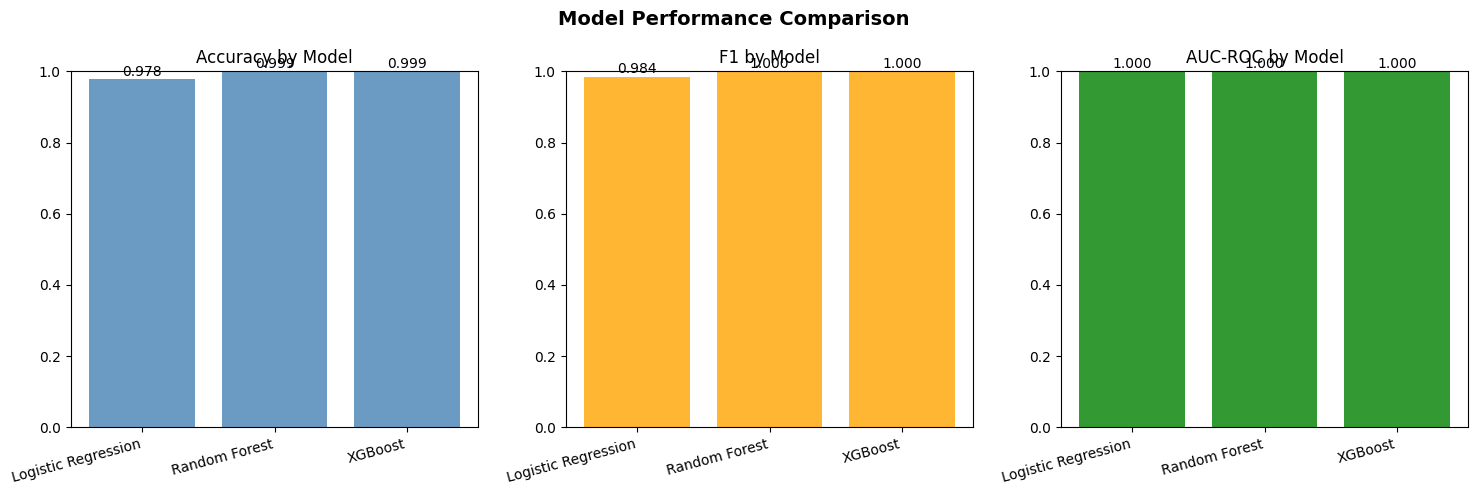

Model comparison plot saved!


In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'F1', 'AUC-ROC']
colors = ['steelblue', 'orange', 'green']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors[i], alpha=0.8)
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED / 'model_comparison.png', dpi=150)
plt.show()
print('Model comparison plot saved!')

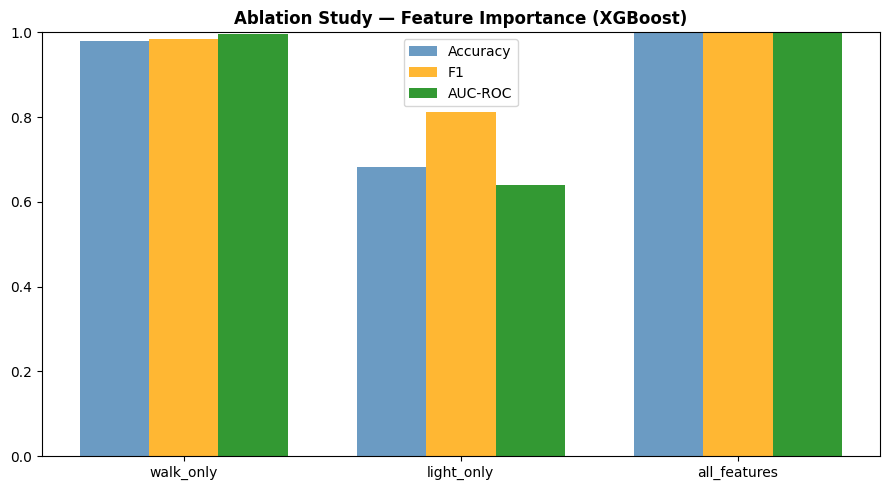

Ablation plot saved!


In [99]:
# Ablation study plot
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ablation_df))
width = 0.25

ax.bar(x - width, ablation_df['Accuracy'], width, label='Accuracy', color='steelblue', alpha=0.8)
ax.bar(x, ablation_df['F1'], width, label='F1', color='orange', alpha=0.8)
ax.bar(x + width, ablation_df['AUC-ROC'], width, label='AUC-ROC', color='green', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ablation_df['Features'])
ax.set_ylim(0, 1)
ax.set_title('Ablation Study — Feature Importance (XGBoost)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / 'ablation_study.png', dpi=150)
plt.show()
print('Ablation plot saved!')

## 6. Confusion Matrix (Best Model)

Classification Report (XGBoost):
              precision    recall  f1-score   support

      Unsafe       1.00      1.00      1.00       499
        Safe       1.00      1.00      1.00      1076

    accuracy                           1.00      1575
   macro avg       1.00      1.00      1.00      1575
weighted avg       1.00      1.00      1.00      1575



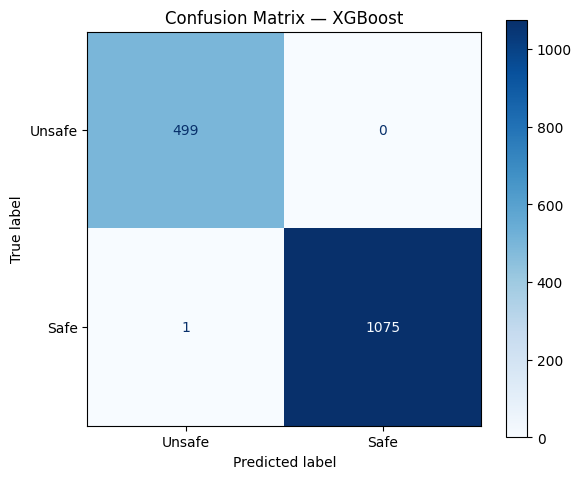

In [100]:
# Use XGBoost (best model)
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)

print('Classification Report (XGBoost):')
print(classification_report(y_test, y_pred_best, target_names=['Unsafe', 'Safe']))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unsafe', 'Safe'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig(PROCESSED / 'confusion_matrix.png', dpi=150)
plt.show()

## 7. SHAP Feature Importance

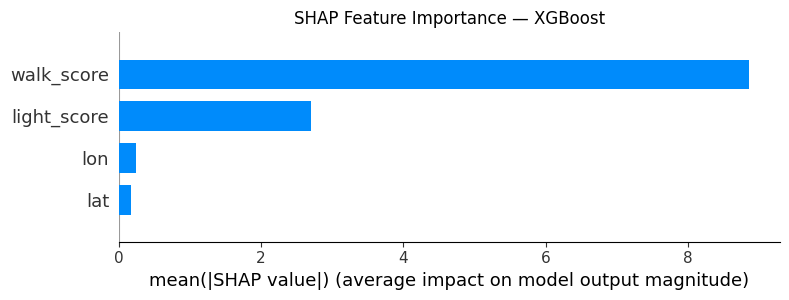

SHAP plot saved!


In [101]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_SETS['all_features'],
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig(PROCESSED / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved!')

## 8. Save Results

In [103]:
# Combine model comparison + ablation
results_df.to_csv(PROCESSED / 'model_results.csv', index=False)
ablation_df.to_csv(PROCESSED / 'ablation_results.csv', index=False)

print('=== FINAL RESULTS ===')
print('\nModel Comparison:')
print(results_df.to_string(index=False))
print('\nAblation Study:')
print(ablation_df.to_string(index=False))

=== FINAL RESULTS ===

Model Comparison:
              Model  Accuracy       F1  AUC-ROC
Logistic Regression  0.977778 0.983982 0.999775
      Random Forest  0.999365 0.999535 1.000000
            XGBoost  0.999365 0.999535 0.999992

Ablation Study:
    Features  Accuracy       F1  AUC-ROC
   walk_only  0.979048 0.984427 0.996724
  light_only  0.683175 0.811769 0.638756
all_features  0.999365 0.999535 0.999992
